# Analitika financija - Druga laboratorijska vježba

---


<b>Uvod i upute za predaju</b>

Druga laboratorijska vježba iz Analitike financija sastoji se od tri zadatka koje je potrebno riješiti u programskom jeziku Python, rješavajući zadatke unutar Juypyter bilježnice. 

Rješavanje vježbe svodi se na čitanje uputa u ćelijama s tekstom, nadopunjavanje blokova kôda (možete dodavati i dodatne blokove kôda ukoliko je potrebno) i ispisivanje rezultata (u vidu ispisa iz funkcija, tablica i grafova). Pritom morate razumjeti teorijske osnove implementiranih rješenja, u okviru onoga što je obrađeno na predavanjima.

Zadatci u samoj vježbi su istraživačkog tipa - ne postoji nužno samo jedan točan način rješavanja svakog zadatka, zato potičemo studente na eksperimentiranje. 

Osim ako u određenom zadatku ne piše drugačije, za implementaciju rješenja možete koristiti proizvoljne biblioteke.

Vaše rješenje (bilježnicu) potrebno je poslati na e-mail adresu `tomislav.kovacevic@fer.hr` u formatu naziva `IME_PREZIME_JMBAG.ipynb`. Na istu e-mail adresu možete se javiti s bilo kakvim pitanjima vezanim uz ovu vježbu.

Na ovoj vježbi možete ostvariti ukupno 20 bodova. Vaša Jupyter bilježnica ocjenjivat će se s mogućnošću ostvarivanja do 5 bodova, a na usmenoj obrani moguće je ostvariti preostalih 15 bodova.
U svom radu smijete koristiti sve alate na raspolaganju (uključujući i alate umjetne inteligencije), ali će se prilikom usmene obrane strogo provjeravati razumijete li sve detalje svog rješenja - ukoliko ne razumijete neki dio vlastitog koda, smatrat će se da taj zadatak niste riješili. Osim toga, provjeravat će se i originalnost rješenja - predstavljanje tuđeg rada kao vlastitog je kršenje kodeksa ponašanja studenata i takvi slučajevi bit će prijavljeni povjerenstvu za stegovnu odgovornost.

Vježbu radite samostalno, a svoje rješenje branite na terminima koji su vam dodijeljeni u kalendaru. Podsjećamo da bodovi iz laboratorijskih vježbi ulaze i u bodove na ispitnom roku, te da je za polaganje predmeta potrebno imati barem 30\% ukupnih bodova iz laboratorijskih vježbi. Nadoknade laboratorijskih vježbi neće biti organizirane.


## Zadatak 1

U ovom zadatku analizirat ćemo Value-at-Risk (VaR) i Expected Shortfall (ES), dvije ključne metrike za kvantificiranje tržišnog rizika. Cilj je procijeniti i usporediti različite metode za izračun VaR-a i ES-a, vizualizirati razlike među metodama te provjeriti koliko su procjene pouzdane kroz jednostavni backtest na novim podacima.

Value-at-Risk (VaR) definiramo kao negativni $(1-\alpha)$-kvantil distribucije povrata $F_R$:

$$
\text{VaR}_\alpha = -F_R^{-1}(1-\alpha),
$$

gdje je $F_R^{-1}$ inverzna funkcija distribucije povrata. 

Value-at-Risk (VaR) odgovara najvećem očekivanom gubitku u X% najgorih scenarija. Međutim, VaR ne daje informaciju o ekstremnim gubicima izvan tog praga. Expected Shortfall (ES) rješava taj problem jer mjeri prosječni gubitak u najgorih X% slučajeva.


Expected Shortfall (ES), poznat i kao Conditional Value-at-Risk (CVaR), definiran je kao prosječna vrijednost Value-at-Risk (VaR) za kvantile iznad razine $\alpha$:

$$
ES_{\alpha}(w) = \frac{1}{1 - \alpha} \int_{\alpha}^{1} \text{VaR}_u(w) \, du,
$$

gdje je:
- $ES_{\alpha}(w)$ – očekivani gubitak uvjetovan time da je ostvaren gubitak veći od VaR-a na razini pouzdanosti $\alpha$,
- $\text{VaR}_{\alpha}(w)$ – Value-at-Risk na razini kvantila $\alpha$,
- $\alpha$ – razina rizika.




1. Koristeći biblioteku `yfinance` dohvatite zadnje cijene u danu (Adj Close) za dionice `AAPL` i `PLTR` u razdoblju 2024-01-01 do 2024-12-31.
2. Implementirajte neparametarsku procjenu ($VaR_\alpha$) i ($ES_\alpha$) koristeći empirijsku distribuciju povrata (uzoračke kvantile iz povijesnih podataka).
3. Prikažite histogram povrata i označite neparametarski dobivene pragove $VaR_{0.95}$ i $ES_{0.95}$. 



[*********************100%***********************]  2 of 2 completed


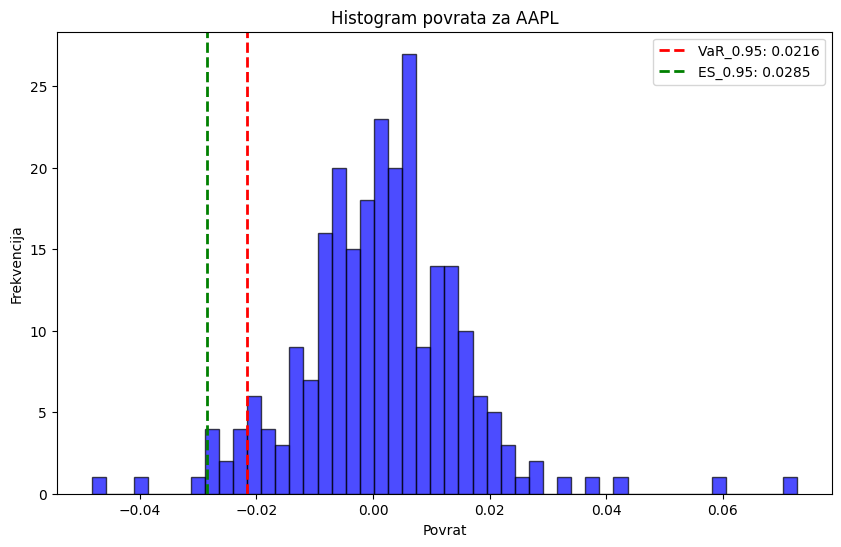

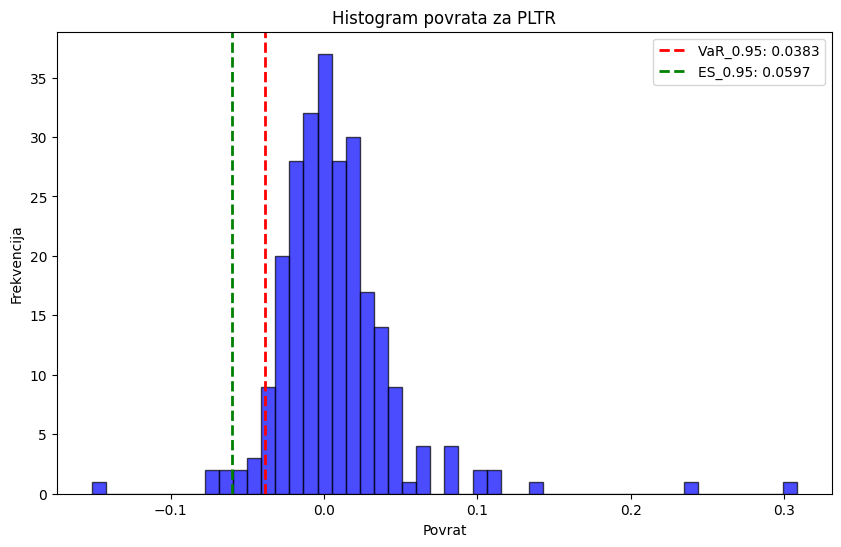

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from scipy.stats import norm
import requests
import io
import zipfile
import re

tickers = ['AAPL', 'PLTR']
start_date = '2024-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']
def calculate_var_es(returns, alpha):
    var = -np.percentile(returns, (1 - alpha) * 100)
    es = -returns[returns <= -var].mean()
    return var, es
alpha = 0.95
var_es_results = {}
for ticker in tickers:
    returns = data[ticker].pct_change().dropna()
    var, es = calculate_var_es(returns, alpha)
    var_es_results[ticker] = (var, es)
    plt.figure(figsize=(10, 6))
    plt.hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(-var, color='red', linestyle='dashed', linewidth=2, label=f'VaR_{alpha}: {var:.4f}')
    plt.axvline(-es, color='green', linestyle='dashed', linewidth=2, label=f'ES_{alpha}: {es:.4f}')
    plt.title(f'Histogram povrata za {ticker}')
    plt.xlabel('Povrat')
    plt.ylabel('Frekvencija')
    plt.legend()
    plt.show()

1. Koristeći biblioteku `yfinance` dohvatite zadnje cijene u danu (Adj Close) za dionice `AAPL` i `PLTR` u razdoblju 2024-01-01 do 2024-12-31.
2.  Implementirajte Gaussovsku parametarsku procjenu (VaR_\alpha) i (ES_\alpha) uz pretpostavku da su povrati normalno distribuirani.
3. Prikažite histogram povrata i označite neparametarski dobivene pragove $VaR_{0.95}$ i $ES_{0.95}$. 

[*********************100%***********************]  2 of 2 completed


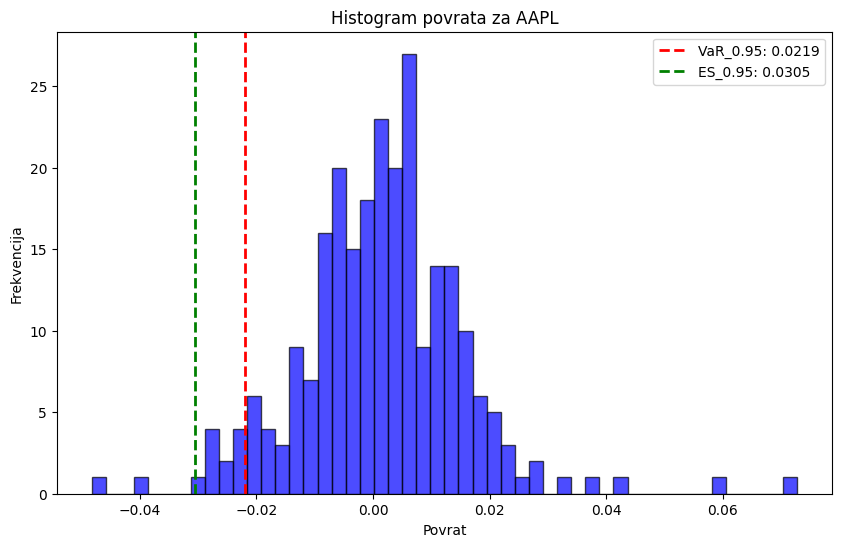

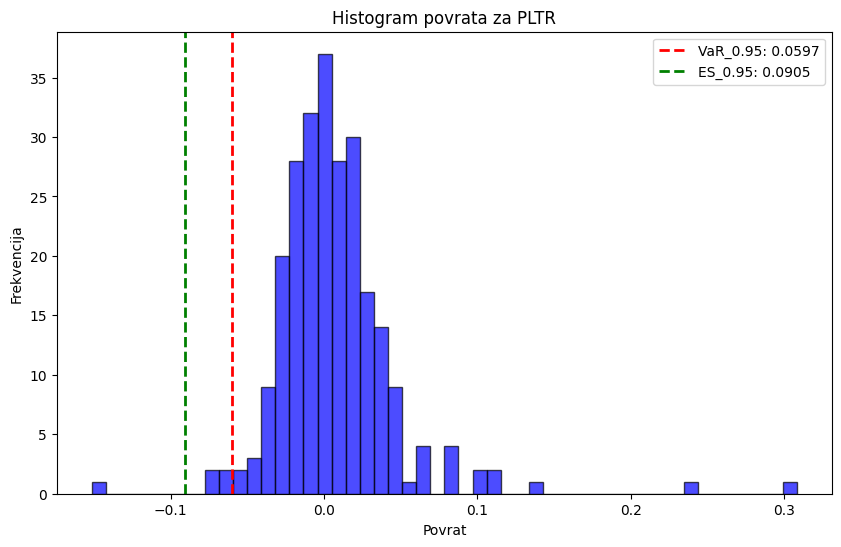

In [2]:
tickers = ['AAPL', 'PLTR']
start_date = '2024-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']

def gaussian_var_es(returns, alpha):
    mu = returns.mean()
    sigma = returns.std()
    var = -(mu + sigma * norm.ppf(1 - alpha))
    es = -(mu + sigma * norm.pdf(norm.ppf(1 - alpha)) / (1 - alpha))
    return var, es

alpha = 0.95
var_es_results = {}
for ticker in tickers:
    returns = data[ticker].pct_change().dropna()
    var, es = gaussian_var_es(returns, alpha)
    var_es_results[ticker] = (var, es)
    plt.figure(figsize=(10, 6))
    plt.hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(-var, color='red', linestyle='dashed', linewidth=2, label=f'VaR_{alpha}: {var:.4f}')
    plt.axvline(es, color='green', linestyle='dashed', linewidth=2, label=f'ES_{alpha}: {-es:.4f}')
    plt.title(f'Histogram povrata za {ticker}')
    plt.xlabel('Povrat')
    plt.ylabel('Frekvencija')
    plt.legend()
    plt.show()

1. Koristeći biblioteku `yfinance` dohvatite zadnje cijene u danu (Adj Close) za dionice `AAPL` i `PLTR` u razdoblju 2025-01-01 do 2025-12-31.
2. Iz prethodnog dijela zadatka preuzmite ranije izračunate vrijednosti neparametarskog (povijesnog) i Gaussovskog parametarskog $VaR_{0.95}$ te ih koristite kao fiksne pragove rizika za novo razdoblje 2025-01-01 do 2025-12-31.
3. Izračunajte stvarne dnevne povrate u novom razdoblju i usporedite ih s neparametarskim i Gaussovskim parametarskim (VaR_{0.95}) pragom. Za svaku dionicu izračunajte postotak dana u kojima je ostvaren “proboj” VaR-a (tj. povrat je lošiji od $VaR_{0.95}$.

In [3]:
tickers = ['AAPL', 'PLTR']
alpha = 0.95

data_2024 = yf.download(tickers, start='2024-01-01', end='2024-12-31', progress=False)['Close']
returns_2024 = data_2024.pct_change().dropna()

var_hist = {}
var_gauss = {}
for t in tickers:
    r = returns_2024[t].dropna()
    v_hist = -np.percentile(r, (1 - alpha) * 100)
    mu = r.mean()
    sigma = r.std(ddof=0)
    v_gauss = -(mu + sigma * norm.ppf(1 - alpha))
    var_hist[t] = v_hist
    var_gauss[t] = v_gauss

data_2025 = yf.download(tickers, start='2025-01-01', end='2025-12-31', progress=False)['Close']
returns_2025 = data_2025.pct_change().dropna()

results = {}
for t in tickers:
    r25 = returns_2025[t].dropna()
    n_days = r25.shape[0]
    breaches_hist = (r25 <= -var_hist[t]).sum()
    breaches_gauss = (r25 <= -var_gauss[t]).sum()
    results[t] = {
        'n_days': int(n_days),
        'var_hist_2024': float(var_hist[t]),
        'var_gauss_2024': float(var_gauss[t]),
        'breaches_hist': int(breaches_hist),
        'breach_pct_hist': float(breaches_hist / n_days * 100) if n_days>0 else np.nan,
        'breaches_gauss': int(breaches_gauss),
        'breach_pct_gauss': float(breaches_gauss / n_days * 100) if n_days>0 else np.nan,
    }

for t, v in results.items():
    print(f"{t}: days={v['n_days']}")
    print(f"  historical VaR_0.95 (from 2024) = {v['var_hist_2024']:.6f}")
    print(f"    breaches: {v['breaches_hist']} ({v['breach_pct_hist']:.2f}%)")
    print(f"  gaussian VaR_0.95 (from 2024)   = {v['var_gauss_2024']:.6f}")
    print(f"    breaches: {v['breaches_gauss']} ({v['breach_pct_gauss']:.2f}%)")
    print()

AAPL: days=248
  historical VaR_0.95 (from 2024) = 0.021574
    breaches: 23 (9.27%)
  gaussian VaR_0.95 (from 2024)   = 0.021869
    breaches: 23 (9.27%)

PLTR: days=248
  historical VaR_0.95 (from 2024) = 0.038341
    breaches: 30 (12.10%)
  gaussian VaR_0.95 (from 2024)   = 0.059560
    breaches: 14 (5.65%)



## Zadatak 2

Razmatramo jednu rizičnu imovinu za koju su poznati njezin očekivani povrat $\mu$ i standardna devijacija povrata $\sigma$, te jednu nerizičnu imovinu za koju je poznat povrat $r_f$.

Zanima nas kakve očekivane povrate i standardne devijacije može imati portfelj ove dvije imovine, ako s $w$ označimo izloženost rizičnoj imovini:

$$
    R_p = (1 - w)r_f + wR
$$
$$
    E(R_p) = r_f + w(\mu - r_f)
$$
$$
    \text{Var}(R_p) = w^2 \sigma^2.
$$

Nadalje, zanima nas koja je optimalna izloženost rizičnoj imovini ako investitori maksimiziraju očekivanu funkciju korisnosti:

$$
    E(U(R_p)) = E(R_p) - \frac{1}{2} \lambda \text{Var}(R_p).
$$

Problem se svodi na:

$$
    \max_w \quad r_f + w(\mu - r_f) - \frac{1}{2} \lambda w^2 \sigma^2, 
$$

a rješenje je:

$$
    w^* = \frac{\mu - r_f}{\lambda \sigma^2}, 
$$

gdje su: 

- $w^*$ - optimalna izloženost rizičnoj imovini,
- $\mu$ - očekivani povrat rizične imovine,
- $r_f$ - povrat nerizične imovine,
- $\lambda$ - koeficijent averzije prema riziku investitora,
- $\sigma$ - standardna devijacija povrata rizične imovine.

1. Koristeći biblioteku `yfinance` dohvatite zadnje dnevne cijene (Adj Close) za dionicu `AAPL` u razdoblju 2024-06-01 do 2024-12-31.
2. Izračunajte dnevne aritmetičke povrate.
3. Implementirajte funkciju `risk_weight(mu, sigma, rf, lmdb)` koja računa optimalni udio u rizičnoj imovini $w^*$ prema gornjoj formuli, uz ograničenje $w^* \in [0,1]$.
4. Pretpostavite godišnju bezrizičnu stopu $$r_f = 2%$$ te za promatrano razdoblje izračunajte:

   * očekivani godišnji povrat $\mu$ kao $\mu = \bar r_{\text{dnevni}} \cdot 252$,
   * godišnju volatilnost $\sigma$ kao $\sigma = s_{\text{dnevni}} \cdot \sqrt{252}$,
   * optimalni udio u dionici $w^*$ za $\lambda = 4$ (uz pretpostavljenu formulu za $w^*$ i ograničenje $w^* \in [0,1]$.

Napomena: $\mu$ i $\sigma$ računajte iz dnevnih aritmetičkih povrata iz točke 2.

In [4]:
tickers = ['AAPL']
start_date = '2024-06-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']

def risk_weight(mu, sigma, rf, lmdb):
    if sigma <= 0:
        return 0.0
    w = (mu - rf) / (lmdb * sigma ** 2)
    return float(np.clip(w, 0.0, 1.0))

returns = data.pct_change().dropna()

r_bar_daily = returns.mean()
s_daily = returns.std(ddof=1)  # sample std
mu = float(r_bar_daily * 252)
sigma = float(s_daily * np.sqrt(252))

rf = 0.02
lmdb = 4.0
w_star = risk_weight(mu, sigma, rf, lmdb)

print(f"Daily mean return: {r_bar_daily}")
print(f"Daily std (sample): {s_daily}")
print(f"Annualized mu: {mu:.6f}")
print(f"Annualized sigma: {sigma:.6f}")
print(f"rf (annual): {rf:.2%}")
print(f"Optimal weight w*: {w_star:.6f}")

[*********************100%***********************]  1 of 1 completed

Daily mean return: Ticker
AAPL    0.001928
dtype: float64
Daily std (sample): Ticker
AAPL    0.014376
dtype: float64
Annualized mu: 0.485796
Annualized sigma: 0.228219
rf (annual): 2.00%
Optimal weight w*: 1.000000



C:\Users\Korisnik\AppData\Local\Temp\ipykernel_5212\3294502645.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(r_bar_daily * 252)
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_5212\3294502645.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(s_daily * np.sqrt(252))


1. Koristeći biblioteku `yfinance` dohvatite zadnje dnevne cijene (Adj Close) za dionicu Coca-Cole (`KO`) u razdoblju **2004-01-01 do 2024-12-31**.
2. Izračunajte dnevne aritmetičke povrate.
3. Implementirajte simulaciju rasta portfelja uz početnu vrijednost (V_0 = 1000). Vrijednost portfelja ažurirajte prema:

$$
V_{t+1} = V_t \left[1 + \left(w^* r_t + (1 - w^*) r_f\right)\right],
$$

gdje je:

* $V_t$ – vrijednost portfelja u trenutku $t$,
* $w^*$ – optimalna težina rizične imovine u portfelju,
* $r_t$ – aritmetički povrat rizične imovine u trenutku $t$,
* $r_f$ – bezrizična stopa povrata.

Rebalans: na početku svake godine ponovno izračunajte $w^*$ (na temelju odabranih $\mu$ i $\sigma$) te taj $w^*$ primjenjujte tijekom cijele te godine, uz udio nerizične imovine $(1-w^*)$.

4. Izvedite tri simulacije rasta portfelja uz godišnju bezrizičnu stopu $r_f = 2%$:

   * (A) Povijesni $\mu$ i $\sigma$: izračunajte očekivani godišnji povrat $\mu$ i godišnju volatilnost $\sigma$ iz dnevnih aritmetičkih povijesnih uzoračkih povrata (uz anualizaciju) te svake godine rebalansirajte portfelj prema izračunatom $w^*$.
   * (B) Fiksni (\mu) + povijesni (\sigma): postavite $\mu = 8%$, a $\sigma$ izračunajte iz dnevnih aritmetičkih povijesnih uzoračkih povrata; svake godine rebalansirajte prema $w^*$.
   * (C) Fiksni (\mu) i (\sigma): postavite $\mu = 8%$ i $\sigma = 15%$, te koristite konstantni udio $w^*$ (bez godišnjeg rebalansa).

5. Iscrtajte tri krivulje rasta vrijednosti portfelja kroz vrijeme za metode (A)–(C) uz koeficijent averzije prema riziku $\lambda = 2$.

6. Ponovite točku 5 i iscrtajte tri krivulje za $\lambda = 1$.

Napomena: Optimalni udio $w^*$ računajte pomoću funkcije `risk_weight(mu, sigma, rf, lmdb)` (iz prethodnog zadatka), uz ograničenje $w^* \in [0,1]$.


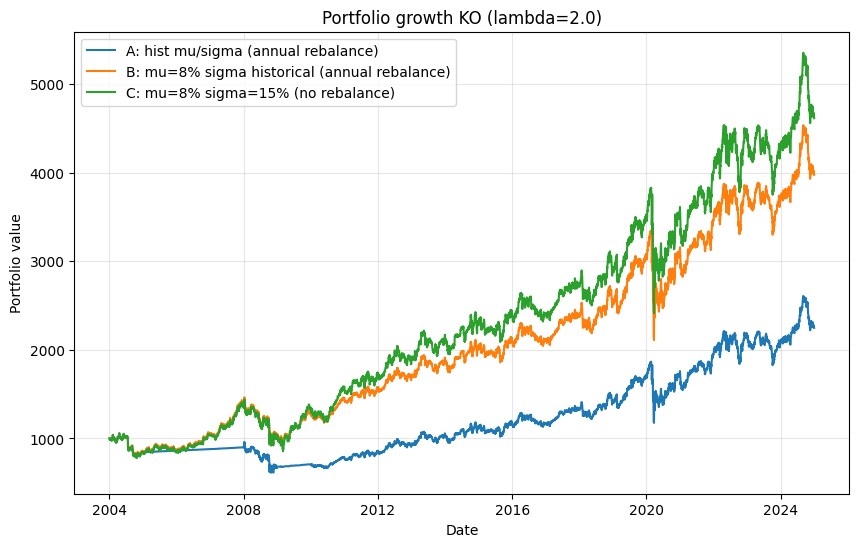

lambda=2.0: final values -> A: 2247.79, B: 3974.00, C: 4612.67


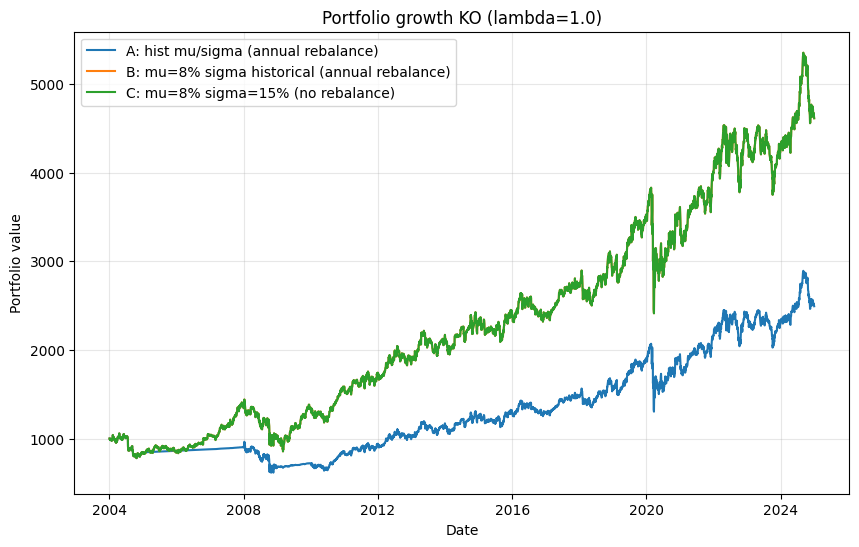

lambda=1.0: final values -> A: 2492.82, B: 4612.67, C: 4612.67


In [5]:
ticker = 'KO'
start = '2004-01-01'
end = '2024-12-31'
rf_annual = 0.02
rf_daily = rf_annual / 252.0  # arithmetic approx
days_per_year = 252

df = yf.download([ticker], start=start, end=end, progress=False)[['Close']].dropna()
df.columns = [ticker]
returns = df[ticker].pct_change().dropna()

# helper: compute historical annualized mu,sigma from a returns Series
def annualize_from_series(r_series):
    r_bar_daily = r_series.mean()
    s_daily = r_series.std(ddof=1)
    mu = r_bar_daily * days_per_year
    sigma = s_daily * np.sqrt(days_per_year)
    return mu, sigma

# get list of years present in returns
years = sorted(list({d.year for d in returns.index}))

def simulate(method, lmdb):
    V0 = 1000.0
    V = V0
    vals = []
    dates = []
    # precompute constant w for method C
    if method == 'C':
        mu_c = 0.08
        sigma_c = 0.15
        w_const = risk_weight(mu_c, sigma_c, rf_annual, lmdb)
    for year in years:
        # determine historical sample up to start of this year
        year_start = pd.Timestamp(datetime(year, 1, 1))
        hist = returns[returns.index < year_start]
        if len(hist) < 20:
            hist = returns[returns.index < year_start] if len(returns[returns.index < year_start])>0 else returns
        if method == 'A':
            mu_h, sigma_h = annualize_from_series(hist)
            w = risk_weight(mu_h, sigma_h, rf_annual, lmdb)
        elif method == 'B':
            mu_fixed = 0.08
            _, sigma_h = annualize_from_series(hist)
            w = risk_weight(mu_fixed, sigma_h, rf_annual, lmdb)
        elif method == 'C':
            w = w_const
        mask = returns.index.year == year
        for dt, r_t in returns[mask].items():
            V = V * (1.0 + (w * r_t + (1.0 - w) * rf_daily))
            vals.append(V)
            dates.append(dt)
    return pd.Series(vals, index=pd.DatetimeIndex(dates), name=method)

# run simulations for lambda = 2 and lambda = 1
for lmdb in [2.0, 1.0]:
    series_A = simulate('A', lmdb)
    series_B = simulate('B', lmdb)
    series_C = simulate('C', lmdb)
    plt.figure(figsize=(10,6))
    plt.plot(series_A.index, series_A.values, label='A: hist mu/sigma (annual rebalance)')
    plt.plot(series_B.index, series_B.values, label='B: mu=8% sigma historical (annual rebalance)')
    plt.plot(series_C.index, series_C.values, label='C: mu=8% sigma=15% (no rebalance)')
    plt.title(f'Portfolio growth KO (lambda={lmdb})')
    plt.xlabel('Date')
    plt.ylabel('Portfolio value')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    print(f"lambda={lmdb}: final values -> A: {series_A.iloc[-1]:.2f}, B: {series_B.iloc[-1]:.2f}, C: {series_C.iloc[-1]:.2f}")

## Zadatak 3

U ovom zadatku istražit ćete odnos između težina u portfelju ponderiranom tržišnim kapitalizacijama i težina u optimalnom Sharpeovom portfelju dobivenom Markowitzovom optimizacijom.

Težine portfelja ponderiranog tržišnim kapitalizacijama definirane su kao:

$$
w_i = \frac{\text{Market Cap}_i}{\sum_j \text{Market Cap}_j},
$$

gdje je težina $w_i$ $i$-te kompanije proporcionalna njezinoj tržišnoj kapitalizaciji u odnosu na ukupnu tržišnu kapitalizaciju portfelja.

1. Koristeći biblioteku `yfinance` dohvatite zadnje cijene u danu (Adj Close) za dionice `AAPL`, `MSFT`, `NVDA`, `TSLA`, `T` u razdoblju 2024-01-01 do 2024-12-31.
2. Koristeći `yfinance` dohvatite tržišne kapitalizacije (`marketCap`) za svaku dionicu i izračunajte težine portfelja ponderiranog tržišnim kapitalizacijama prema gornjoj formuli.

   * Dobivene težine koristite kao fiksne težine portfelja u cijelom promatranom razdoblju.
3. Preuzmite dnevnu bezrizičnu stopu (R_f) iz Fama–French baze podataka za isto razdoblje (2024-01-01 do 2024-12-31)
   * https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip
4. Izračunajte dnevne povrate pojedinačnih dionica i zatim dnevne povrate portfelja ponderiranog tržišnim kapitalizacijama kao ponderirani zbroj povrata dionica (koristeći težine iz točke 2) za razdoblje 2024-01-01 do 2024-12-31.


In [15]:
tickers = ["AAPL", "MSFT", "NVDA", "T", "TSLA"]
start_date = "2024-01-01"
end_date = "2024-12-31"

prices = yf.download(tickers,start=start_date,end=end_date,auto_adjust=False)["Close"]

prices.dropna(inplace=True)

market_caps = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)
    market_caps[ticker] = stock.info["marketCap"]

market_caps = pd.Series(market_caps)
weights_mktcap = market_caps / market_caps.sum()

returns = prices.pct_change().dropna()

Rm = returns @ weights_mktcap
Rm.name = "Rm"

ff_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"

ff_data = pd.read_csv(
    ff_url,
    skiprows=3,
    index_col=0
)

ff_data = ff_data[ff_data.index.str.match(r"^\d{8}$")]
ff_data.index = pd.to_datetime(ff_data.index, format="%Y%m%d")
ff_data = ff_data.loc[start_date:end_date]

Rf = ff_data["RF"]
Rf.name = "Rf"

#print(weights_mktcap)

print("dnevni povrati pojedinačnih dionica", returns.head(), sep="\n")
print("\ndnevni povrati portfelja ponderiranog tržišnim kapitalizacijama", Rm.head(), sep="\n")


[*********************100%***********************]  5 of 5 completed


dnevni povrati pojedinačnih dionica
Ticker          AAPL      MSFT      NVDA         T      TSLA
Date                                                        
2024-01-03 -0.007488 -0.000728 -0.012436 -0.001159 -0.040134
2024-01-04 -0.012700 -0.007178  0.009018 -0.004643 -0.002181
2024-01-05 -0.004013 -0.000516  0.022897  0.018659 -0.001849
2024-01-08  0.024175  0.018872  0.064281 -0.008586  0.012464
2024-01-09 -0.002263  0.002936  0.016975 -0.021363 -0.022832

dnevni povrati portfelja ponderiranog tržišnim kapitalizacijama
Date
2024-01-03   -0.010915
2024-01-04   -0.002665
2024-01-05    0.006538
2024-01-08    0.034742
2024-01-09    0.003116
Name: Rm, dtype: float64


Prilagodite CAPM za svaku od dionica: `AAPL`, `MSFT`, `NVDA`, `TSLA`, `T` u razdoblju od 2024-01-01 do 2024-12-31. 
Koristite prethodno izračunate povrate portfelja ponderiranom tržišnim kapitalizacijama. Dnevne povrate imovina i tržišnog portfelja umanjite za preuzetu bezrizična stopu. 
Koeficijent $\beta$ može se procijeniti korištenjem metode najmanjih kvadrata (OLS), tj. $\beta$ se definira kao omjer kovarijance povrata dionice i tržišnog portfelja te varijance tržišnog portfelja:

$$
\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}, 
$$

gdje su $\text{Cov}(R_i, R_m)$ kovarijanca povrata dionice $R_i$ i povrata portfelja ponderiranom tržišnim kapitalizacijama $R_m$, a $\text{Var}(R_m)$ varijanca povrata portfelja ponderiranom tržišnim kapitalizacijama. 

Capital Asset Pricing Model (CAPM) koristi se za procjenu očekivanog povrata pojedine dionice u odnosu na sistemski (tržišni) rizik:

$$
E(R_i) = R_f + \beta_i\bigl(E(R_m) - R_f\bigr),
$$

gdje su:

* $R_f$ – prosječna dnevna bezrizična stopa tijekom promatranog razdoblja (preuzeta iz Fama–French baze podataka),
* $\beta_i$ – koeficijent koji mjeri osjetljivost povrata dionice na tržišni portfelj,
* $E(R_m)$ – očekivani povrat tržišnog portfelja,
* $E(R_m) - R_f$ – premija tržišnog rizika.

U ovom zadatku tržišni portfelj (R_m) aproksimirajte portfeljem ponderiranim tržišnim kapitalizacijama konstruiranim u prethodnom zadatku od dionica `AAPL`, `MSFT`, `NVDA`, `TSLA`, `T`.

Prilagodite CAPM za svaku od dionica `AAPL`, `MSFT`, `NVDA`, `TSLA`, `T` u razdoblju 2024-01-01 do 2024-12-31. Koristite prethodno izračunate dnevne povrate portfelja ponderiranog tržišnim kapitalizacijama kao (R_m). Dnevne povrate dionica i tržišnog portfelja umanjite za bezrizičnu stopu.

Koeficijent $\beta_i$ može se procijeniti metodom najmanjih kvadrata (OLS), a ekvivalentno se može zapisati kao omjer kovarijance i varijance:

$$
\beta_i = \frac{\mathrm{Cov}(R_i^{e},, R_m^{e})}{\mathrm{Var}(R_m^{e})},
\quad \text{gdje je } ;
R_i^{e} = R_i - R_f,;; R_m^{e} = R_m - R_f.
$$

Ovdje je $\mathrm{Cov}(R_i^{e}, R_m^{e})$ kovarijanca povrata dionice i povrata portfelja ponderiranog tržišnim kapitalizacijama (umanjenih za bezrizičnu stopu), a $\mathrm{Var}(R_m^{e})$ varijanca povrata tog portfelja umenjenog za bezrizičnu stopu.


In [14]:
combined = pd.concat([Ri_excess, Rm_excess.rename("Rm_excess")], axis=1).dropna()

Rm_excess_clean = combined["Rm_excess"]
Ri_excess_clean = combined[returns.columns]  # same column order

var_m = Rm_excess_clean.var()
covs = Ri_excess_clean.apply(lambda s: s.cov(Rm_excess_clean))
betas = (covs / var_m).rename("Beta")
print(betas)


AAPL    0.495271
MSFT    0.517810
NVDA    1.733407
T      -0.209567
TSLA    1.298195
Name: Beta, dtype: float64


Izračunajte očekivane povrate pojedine dionice u razdoblju od 2024-01-01 do 2024-12-31 koristeći CAPM.

In [8]:
E_Rf = Rf.mean()
E_Rm = Rm.mean()
market_premium = E_Rm - E_Rf

E_Ri = E_Rf + betas * market_premium
E_Ri.name = "CAPM Expected Return (Daily)"

mu_capm = E_Ri.copy()
mu_capm.name = "CAPM Expected Return"
print("očekivani povrati pojedine dionice koristeći CAPM:", mu_capm, sep="\n")

očekivani povrati pojedine dionice koristeći CAPM:
AAPL    0.011319
MSFT    0.010924
NVDA   -0.010384
T       0.023673
TSLA   -0.002755
Name: CAPM Expected Return, dtype: float64


Markowitzova teorija određuje portfelj s maksimalnim Sharpeovim omjerom, maksimizirajući:

$$
\max_w \frac{w^T \mu - R_f}{\sqrt{w^T \Sigma w}}
$$

gdje su:

- $\mu$ – vektor očekivanih povrata (dobiven iz CAPM-a),
- $\Sigma$ – kovarijacijska matrica povrata imovine,
- $w$ – vektor težina portfelja,
- $R_f$ - : prosječna dnevna bezrizična stopa tijekom promatranog razdoblja.

Odredite težine pojedine dionice u portfelju s maksimalnim Sharpeovim omjerom,  koriteći Koristeći CAPM očekivane povrate i kovarijacijsku matricu.

In [9]:
# težine pojedine dionice u portfelju s maksimalnim Sharpeovim omjerom
Sigma = returns.cov()
mu_excess = mu_capm - E_Rf
Sigma_inv = np.linalg.inv(Sigma.values)
w_star_raw = Sigma_inv @ mu_excess.values
w_star = w_star_raw / w_star_raw.sum()
weights_markowitz = pd.Series(
    w_star,
    index=tickers,
    name="Markowitz Max Sharpe Weight"
)
print("težine pojedine dionice u portfelju s maksimalnim Sharpeovim omjerom:", weights_markowitz, sep="\n")


težine pojedine dionice u portfelju s maksimalnim Sharpeovim omjerom:
AAPL    0.282860
MSFT    0.256085
NVDA    0.339459
T       0.012583
TSLA    0.109014
Name: Markowitz Max Sharpe Weight, dtype: float64


Ispišite težine MCWP portfelja i Markowitz optimalnog portfelja.

In [10]:
comparison = pd.DataFrame({
    "MCWP Weight": weights_mktcap,
    "Markowitz Max Sharpe Weight": weights_markowitz
})

comparison

,MCWP Weight,Markowitz Max Sharpe Weight
AAPL,0.282860,0.282860
MSFT,0.256085,0.256085
NVDA,0.339459,0.339459
T,0.012583,0.012583
TSLA,0.109014,0.109014
